In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [3]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [4]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_0.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657408,0.633996
1,3.900000e-09,0.715507,0.693300
2,5.900000e-09,0.768876,0.748785
3,7.900000e-09,0.815332,0.798178
4,9.900000e-09,0.852972,0.839454
...,...,...,...
535,6.390000e-08,0.675195,0.896826
536,6.590000e-08,0.495811,0.300688
537,6.790000e-08,0.732116,0.898728
538,6.990000e-08,0.441311,0.304921


In [5]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [6]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

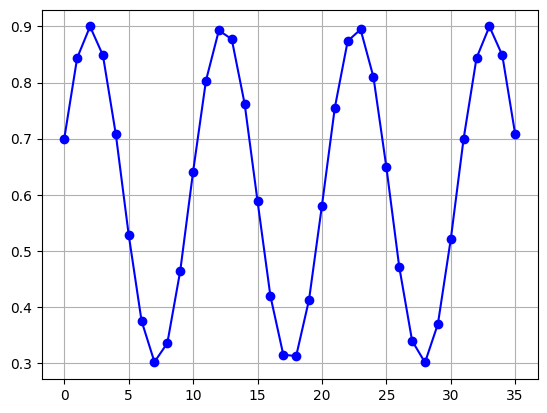

In [7]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [8]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-3.0785003935219895e-08
-2.1781136424038016e-08
-9.834954719531206e-08
3.145574256482125e-08
-1.052439835937233e-06
-9.450690380100919e-07
8.432977620369781e-07
-2.2156125584430614e-07
-2.5730527440265974e-07
-4.459368928254081e-07
-1.7540542842409542e-06
-1.6037996902468715e-07
9.16535476879741e-06
5.289212210113762e-06
-9.459998090870976e-06
-3.320061495938081e-07
-2.8042838688763574e-07
-4.2447047259540583e-07
-2.650282658443494e-06
-1.9161464307307233e-06
-9.475354065374353e-07
-1.0681731999855367e-06
-2.2158257623456452e-07
3.5052541605688353e-05
4.892798667085255e-07
-9.349508129888175e-07
-3.043221031466167e-06
-5.64726822720035e-05
2.6163039856612826e-05
-2.6229783884984154e-06


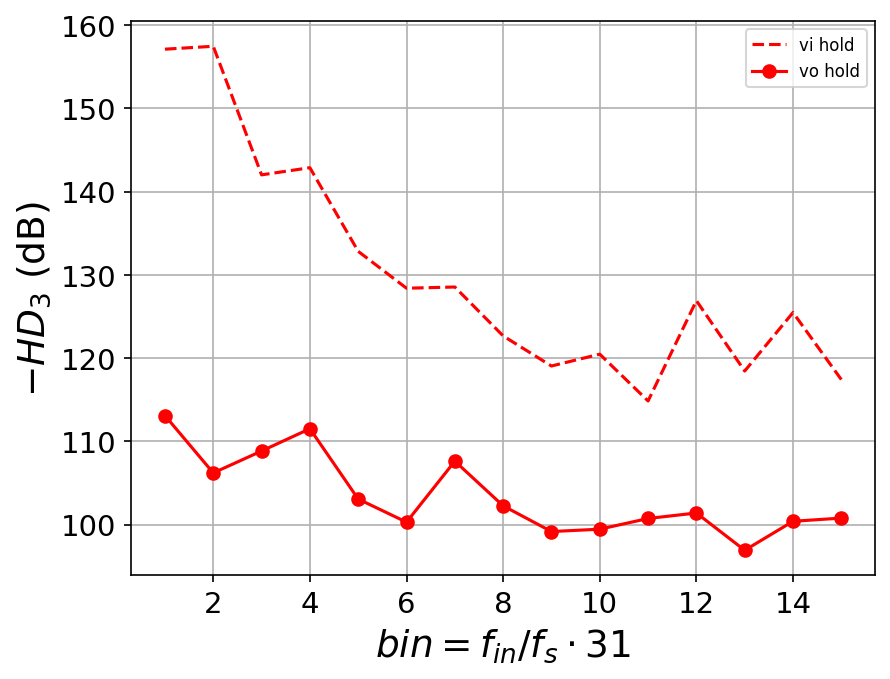

In [9]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "r-o", label='vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(50, 140)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-3.320061495938081e-07
-2.8042838688763574e-07
-4.2447047259540583e-07
-2.650282658443494e-06
-1.9161464307307233e-06
-9.475354065374353e-07
-1.0681731999855367e-06
-2.2158257623456452e-07
3.5052541605688353e-05
4.892798667085255e-07
-9.349508129888175e-07
-3.043221031466167e-06
-5.64726822720035e-05
2.6163039856612826e-05
-2.6229783884984154e-06


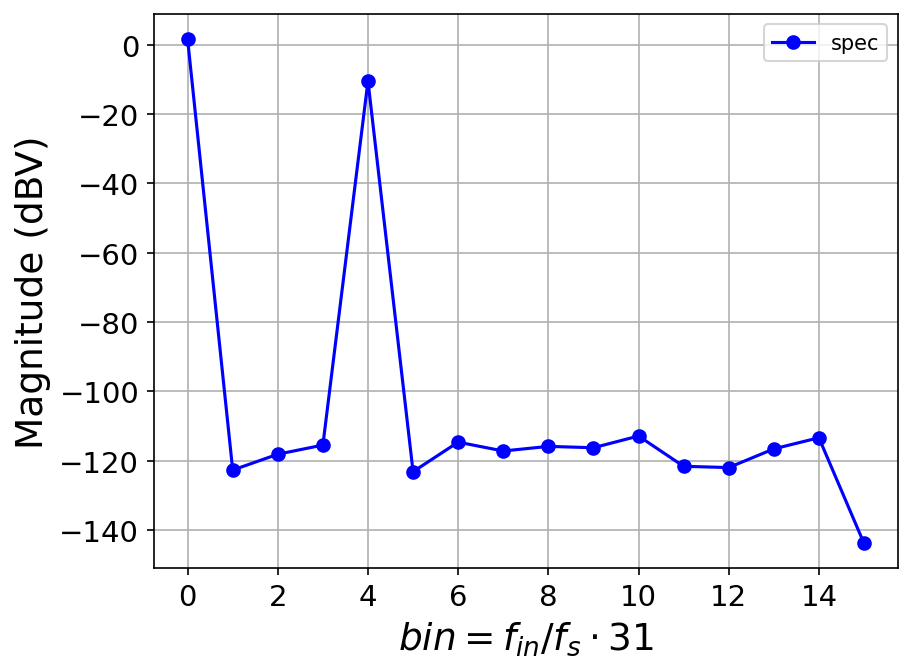

In [10]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()
